<a href="https://colab.research.google.com/github/josenomberto/UTEC-CDIAV3-MCD8010/blob/main/proyecto1_v1.1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MCD8010 - MACHINE LEARNING

## Regression Challenge 1: Online News Popularity

*   Alejandro Pinedo
*   David Jimenez
*   Jose Carlos Nomberto

## Objectivo:
Predecit the number of shares of online news

# 1. Analisis Exploratorio (EDA)


Se realiza el Análisis Exploratorio de Datos (EDA) en el conjunto de datos `OnlineNewsPopularity.csv`, que incluye la inspección inicial de los datos, estadísticas descriptivas, análisis de la variable objetivo ('shares'), identificación de valores atípicos y ruido, y análisis de correlación. Finalmente, se resumen los hallazgos sobre las características del conjunto de datos, la etiqueta objetivo, el tamaño, los tipos de datos, los valores faltantes, los valores atípicos identificados, el ruido y cualquier posible desequilibrio.

## 1.1 Importar librerias requeridas

Importar librerias requeridas: pandas, matplotlib, seaborn, etc

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler


## 1.2 Carga de base de datos


Se carga el conjunto de datos `OnlineNewsPopularity.csv` en un DataFrame de pandas llamado `df` y se muestran las primeras filas para verificación

In [7]:
#print("\n1. Loading Dataset into dataframe.")
#try:
#  df = pd.read_csv('/content/OnlineNewsPopularity.csv')
#  print("\n     Dataset loaded successfully.")
#  df.head()
#except Exception as e:
#  print(f"\n     Error loading dataset: {e}")

print("\n1. Cargando base de datos en dataframe.")
df = pd.read_csv('/content/OnlineNewsPopularity.csv')
print("\n     Base de Datos cargada correctamente.")
df.head()



1. Loading Dataset into dataframe.

     Dataset loaded successfully.


,url,timedelta,n_tokens_title,n_tokens_content,n_unique_tokens,n_non_stop_words,n_non_stop_unique_tokens,num_hrefs,num_self_hrefs,num_imgs,...,min_positive_polarity,max_positive_polarity,avg_negative_polarity,min_negative_polarity,max_negative_polarity,title_subjectivity,title_sentiment_polarity,abs_title_subjectivity,abs_title_sentiment_polarity,shares
0,http://mashable.com/2013/01/07/amazon-instant-...,731.0,12.0,219.0,0.663594,1.0,0.815385,4.0,2.0,1.0,...,0.100000,0.7,-0.350000,-0.600,-0.200000,0.500000,-0.187500,0.000000,0.187500,593
1,http://mashable.com/2013/01/07/ap-samsung-spon...,731.0,9.0,255.0,0.604743,1.0,0.791946,3.0,1.0,1.0,...,0.033333,0.7,-0.118750,-0.125,-0.100000,0.000000,0.000000,0.500000,0.000000,711
2,http://mashable.com/2013/01/07/apple-40-billio...,731.0,9.0,211.0,0.575130,1.0,0.663866,3.0,1.0,1.0,...,0.100000,1.0,-0.466667,-0.800,-0.133333,0.000000,0.000000,0.500000,0.000000,1500
3,http://mashable.com/2013/01/07/astronaut-notre...,731.0,9.0,531.0,0.503788,1.0,0.665635,9.0,0.0,1.0,...,0.136364,0.8,-0.369697,-0.600,-0.166667,0.000000,0.000000,0.500000,0.000000,1200
4,http://mashable.com/2013/01/07/att-u-verse-apps/,731.0,13.0,1072.0,0.415646,1.0,0.540890,19.0,19.0,20.0,...,0.033333,1.0,-0.220192,-0.500,-0.050000,0.454545,0.136364,0.045455,0.136364,505


## 1.2 Inspección Inicial de datos


Se realiza la inspección inicial de los datos:

* Mostrar las dimensiones (número de filas y columnas) del DataFrame mediante el atributo .shape para validar su tamaño.
* Mostrar un resumen del DataFrame, incluyendo los tipos de datos y los valores no nulos mediante el método .info().
* Identificar los valores faltantes en el conjunto de datos mediante los métodos .isnull().sum() en el df del DataFrame.




In [8]:
print(f"\n2. Inpección Inicial de Datos")

print(f"\n2.1 Dimensiones:")
print(f"Dimensiones de la base de datos: {df.shape[0]} filas, {df.shape[1]} columnas")

print(f"\n2.1 Info:")
df.info()
df.describe()

print(f"\n2.2 Valores faltantes:")
missing_values = df.isnull().sum()
print("Valores faltantes por columna:")
#print(missing_values[missing_values > 0])
print(missing_values)
print(f"{missing_values[missing_values > 0]}")



2. Inpección Inicial de Datos

2.1 Dimensiones:
Dimensiones de la base de datos: 39644 filas, 61 columnas

2.1 Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 39644 entries, 0 to 39643
Data columns (total 61 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   url                             39644 non-null  object 
 1    timedelta                      39644 non-null  float64
 2    n_tokens_title                 39644 non-null  float64
 3    n_tokens_content               39644 non-null  float64
 4    n_unique_tokens                39644 non-null  float64
 5    n_non_stop_words               39644 non-null  float64
 6    n_non_stop_unique_tokens       39644 non-null  float64
 7    num_hrefs                      39644 non-null  float64
 8    num_self_hrefs                 39644 non-null  float64
 9    num_imgs                       39644 non-null  float64
 10   num_videos                     3964

## 1.2 Análisis Descriptivo


Genere estadísticas descriptivas para todas las columnas numéricas usando `df.describe()` para obtener un resumen de la tendencia central, la dispersión y la forma de la distribución, lo que puede ayudar a identificar posibles valores atípicos.


In [9]:
#descriptive_stats = df.describe()
#print("Descriptive Statistics for Numerical Columns:")
#print(descriptive_stats)

print(f"\n3. Estadisticas descriptivas para variable numéricas")

df.describe()


3. Estadisticas descriptivas para variable numéricas


,timedelta,n_tokens_title,n_tokens_content,n_unique_tokens,n_non_stop_words,n_non_stop_unique_tokens,num_hrefs,num_self_hrefs,num_imgs,num_videos,...,min_positive_polarity,max_positive_polarity,avg_negative_polarity,min_negative_polarity,max_negative_polarity,title_subjectivity,title_sentiment_polarity,abs_title_subjectivity,abs_title_sentiment_polarity,shares
count,39644.000000,39644.000000,39644.000000,39644.000000,39644.000000,39644.000000,39644.000000,39644.000000,39644.000000,39644.000000,...,39644.000000,39644.000000,39644.000000,39644.000000,39644.000000,39644.000000,39644.000000,39644.000000,39644.000000,39644.000000
mean,354.530471,10.398749,546.514731,0.548216,0.996469,0.689175,10.883690,3.293638,4.544143,1.249874,...,0.095446,0.756728,-0.259524,-0.521944,-0.107500,0.282353,0.071425,0.341843,0.156064,3395.380184
std,214.163767,2.114037,471.107508,3.520708,5.231231,3.264816,11.332017,3.855141,8.309434,4.107855,...,0.071315,0.247786,0.127726,0.290290,0.095373,0.324247,0.265450,0.188791,0.226294,11626.950749
min,8.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,-1.000000,-1.000000,-1.000000,0.000000,-1.000000,0.000000,0.000000,1.000000
25%,164.000000,9.000000,246.000000,0.470870,1.000000,0.625739,4.000000,1.000000,1.000000,0.000000,...,0.050000,0.600000,-0.328383,-0.700000,-0.125000,0.000000,0.000000,0.166667,0.000000,946.000000
50%,339.000000,10.000000,409.000000,0.539226,1.000000,0.690476,8.000000,3.000000,1.000000,0.000000,...,0.100000,0.800000,-0.253333,-0.500000,-0.100000,0.150000,0.000000,0.500000,0.000000,1400.000000
75%,542.000000,12.000000,716.000000,0.608696,1.000000,0.754630,14.000000,4.000000,4.000000,1.000000,...,0.100000,1.000000,-0.186905,-0.300000,-0.050000,0.500000,0.150000,0.500000,0.250000,2800.000000
max,731.000000,23.000000,8474.000000,701.000000,1042.000000,650.000000,304.000000,116.000000,128.000000,91.000000,...,1.000000,1.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.500000,1.000000,843300.000000


## 1.4 Análisis de la variable objetivo

Analice la distribución de la variable objetivo, "participaciones", mediante un histograma y un diagrama de caja. Este paso ayudará a identificar su distribución, asimetría y la presencia de valores atípicos.

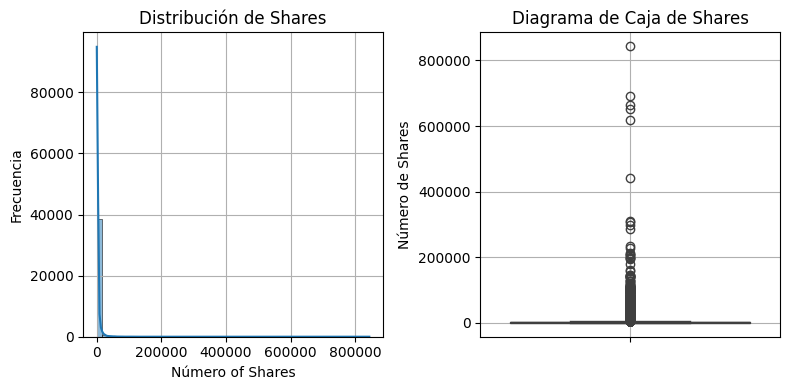

In [14]:
#import matplotlib.pyplot as plt
#import seaborn as sns

# Crea histograma de la columna "shares"

#print(df.columns)
plt.figure(figsize=(8, 4))

plt.subplot(1, 2, 1) # Selecciona el primer plot en 1x2
sns.histplot(df[' shares'], bins=50, kde=True)
plt.title('Distribución de Shares')
plt.xlabel('Número of Shares')
plt.ylabel('Frecuencia')
plt.grid(True)
#plt.show()

# Crea diagrama de caja de la columna "shares"
plt.subplot(1, 2, 2) # # Selecciona el segundo plot en 1x2
#plt.figure(figsize=(6, 3))
sns.boxplot(y=df[' shares'])
plt.title('Diagrama de Caja de Shares')
plt.ylabel('Número de Shares')
plt.grid(True)
#plt.show()

plt.tight_layout()

plt.show()


## 1.5 Identificar valores atípicos y ruido

Visualice la distribución de características numéricas clave utilizando histogramas y diagramas de caja para identificar posibles valores atípicos, asimetrías y ruido que podrían afectar el modelo de regresión.


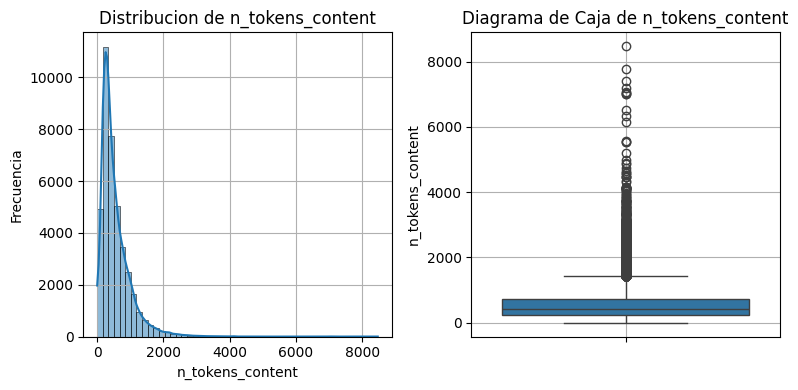

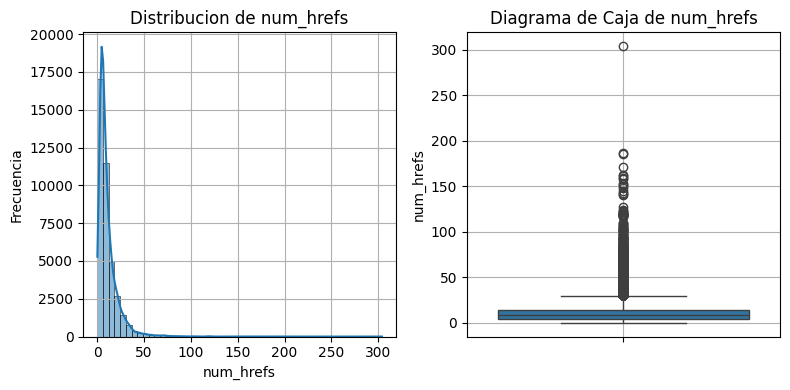

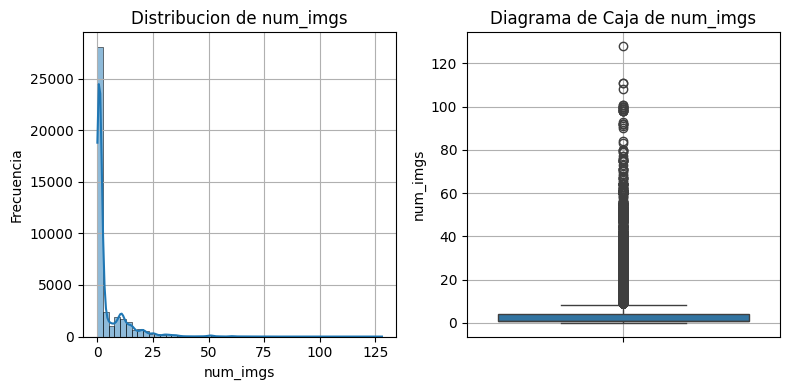

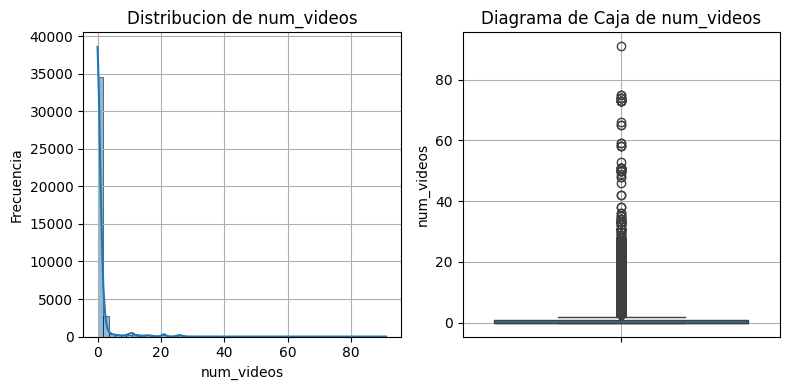

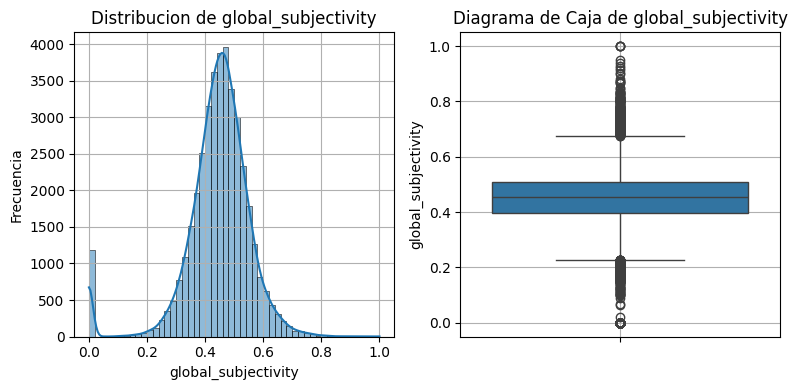

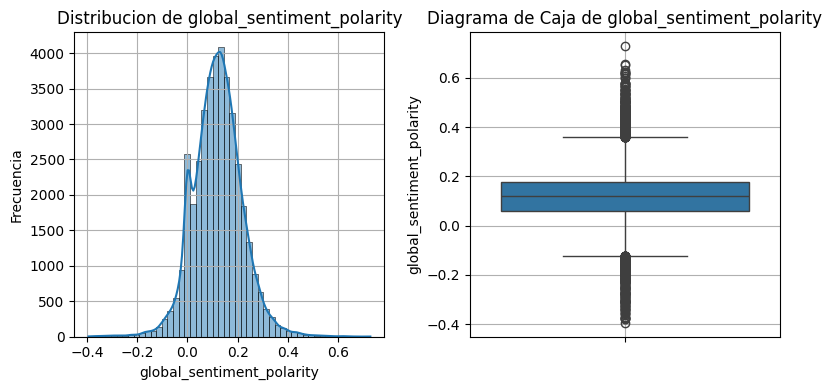

In [17]:
key_features = [' n_tokens_content', ' num_hrefs', ' num_imgs', ' num_videos', ' global_subjectivity', ' global_sentiment_polarity']

for feature in key_features:
    # Crea histograma
    plt.figure(figsize=(8, 4))
    plt.subplot(1, 2, 1) # Selecciona el primer plot en 1x2
    #plt.figure(figsize=(12, 5))
    sns.histplot(df[feature], bins=50, kde=True)
    plt.title(f'Distribucion de {feature.strip()}')
    plt.xlabel(feature.strip())
    plt.ylabel('Frecuencia')
    plt.grid(True)
    #plt.show()

    # Crea diagrama de caja
    plt.subplot(1, 2, 2) # # Selecciona el segundo plot en 1x2
    #plt.figure(figsize=(12, 5))
    sns.boxplot(y=df[feature])
    plt.title(f'Diagrama de Caja de {feature.strip()}')
    plt.ylabel(feature.strip())
    plt.grid(True)
    #plt.show()

    plt.tight_layout()

    plt.show()


## 1.6 Análisis de Correlación

Calcular y visualizar la matriz de correlación entre todas las características numéricas y la variable objetivo 'shares'.



Correlaciones con columna 'shares':
kw_avg_avg                       0.110413
LDA_03                           0.083771
kw_max_avg                       0.064306
self_reference_avg_sharess       0.057789
self_reference_min_shares        0.055958
self_reference_max_shares        0.047115
num_hrefs                        0.045404
kw_avg_max                       0.044686
kw_min_avg                       0.039551
num_imgs                         0.039388
global_subjectivity              0.031604
kw_avg_min                       0.030406
kw_max_min                       0.030114
abs_title_sentiment_polarity     0.027135
num_videos                       0.023936
title_subjectivity               0.021967
num_keywords                     0.021818
is_weekend                       0.016958
weekday_is_saturday              0.015082
title_sentiment_polarity         0.012772
avg_positive_polarity            0.012142
max_positive_polarity            0.010068
weekday_is_monday                0.0097

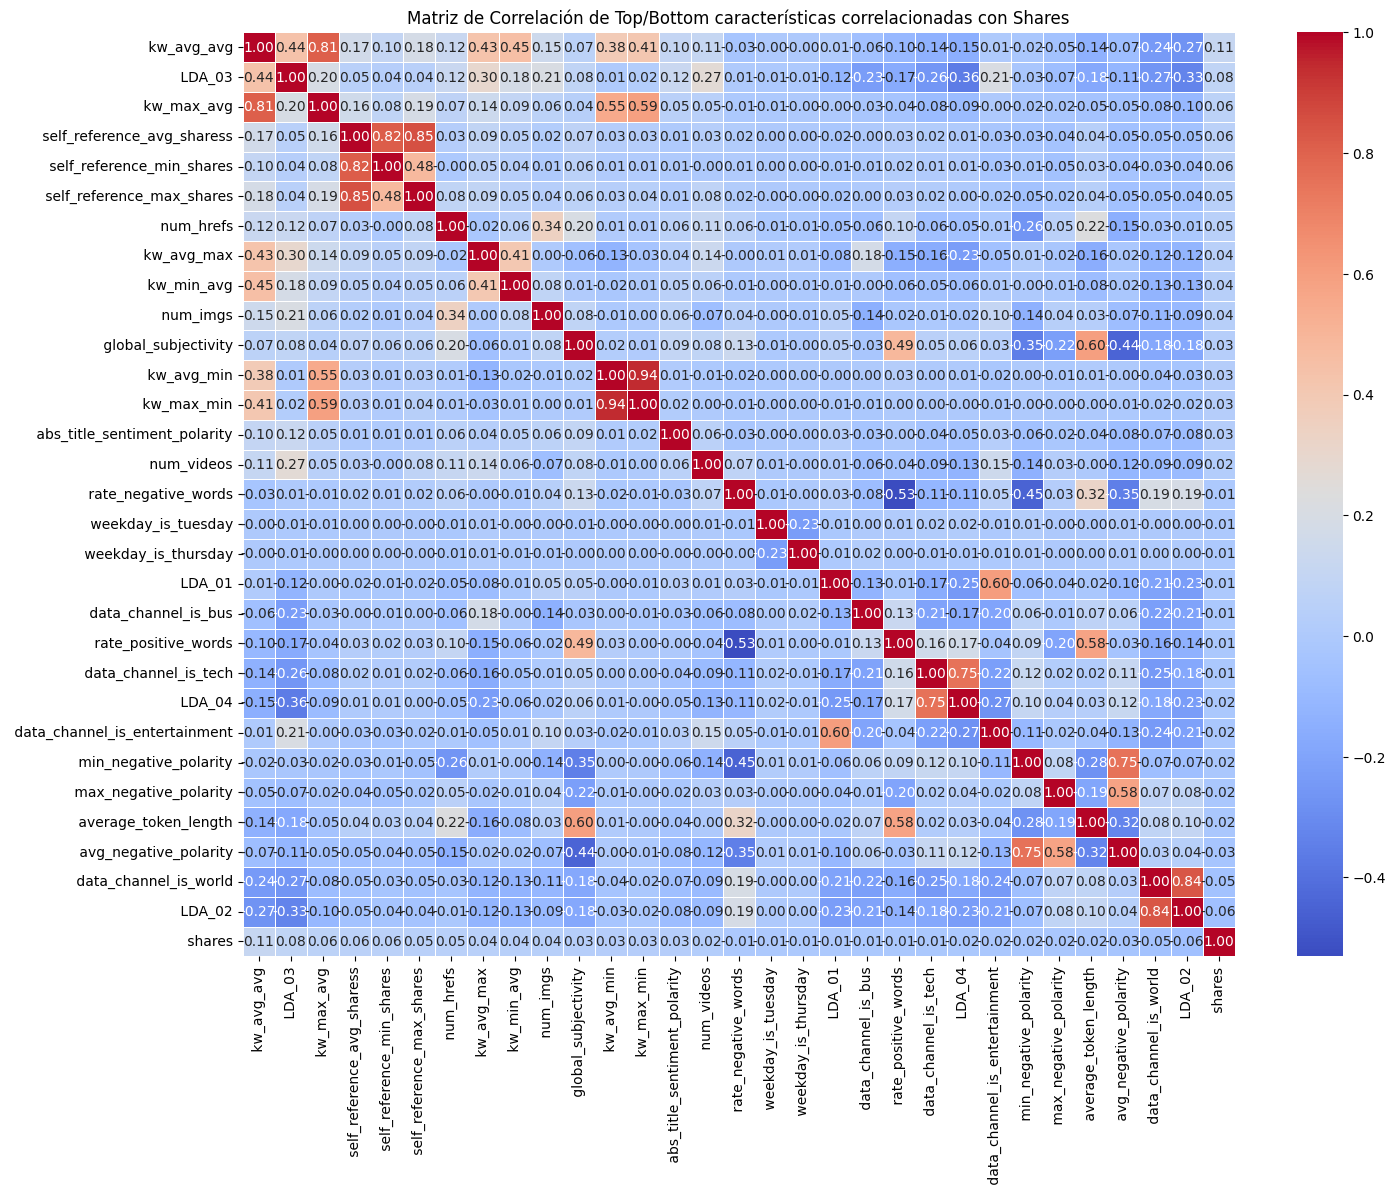

In [18]:
#import matplotlib.pyplot as plt
#import seaborn as sns

# Crea una copia del Dataframe y descarta la columna 'url (non-numerical)
df_numerical = df.drop('url', axis=1)

# 1. Calcula la matriz de correlación
correlation_matrix = df_numerical.corr()

# 2. Extrae las correlaciones con la columna ' shares'
shares_correlation = correlation_matrix[' shares'].sort_values(ascending=False)

# 3. Excluye ' shares' de la lista
shares_correlation = shares_correlation.drop(' shares')

print("\nCorrelaciones con columna 'shares':")
print(shares_correlation)

# 4. Muestra las top 10 caracteristicas más correlacionadas
print("\nTop 10 características más correlacionadas con 'shares':")
print(shares_correlation.head(10))

# Muestra las botton 10 caracteristicas menos correlacionadas
print("\nBottom 10 características menos correlacionadas con 'shares':")
print(shares_correlation.tail(10))

# 5. Crea un heatmap para un subconjunto de la matriz de correlación
# Selecciona los top 15 positivos and top 15 negativos características correlacionadas para visualización
top_correlated_features = shares_correlation.head(15).index.tolist()
bottom_correlated_features = shares_correlation.tail(15).index.tolist()
selected_features = top_correlated_features + bottom_correlated_features + [' shares']

plt.figure(figsize=(16, 12))
sns.heatmap(df_numerical[selected_features].corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Matriz de Correlación de Top/Bottom características correlacionadas con Shares')
plt.show()


## 1.7 Resumen de los hallazgos del Análisis Exploratorio

### Resumen del conjunto de datos
- **Tamaño**: El conjunto de datos contiene `39644` filas y `61` columnas.
- **Tipos de datos**: El conjunto de datos se compone principalmente de características numéricas (`float64` e `int64`), con una columna de tipo `object` (`url`).
- **Valores faltantes**: No hay valores faltantes en ninguna de las columnas.

### Análisis de la variable objetivo ('shares')
- **Distribución**: La variable `shares` presenta una marcada desviación a la derecha, lo que muestra que la mayoría de los artículos reciben un número relativamente bajo de compartidos, mientras que un pequeño número de artículos se viralizan y reciben un número muy alto de compartidos. Esto se evidencia tanto en el histograma como en el diagrama de caja.
- **Valores atípicos**: el diagrama de caja muestra claramente una cantidad significativa de valores atípicos para los compartidos, con valores que se extienden mucho más allá de la distribución principal, lo que sugiere que los artículos muy populares son comunes en el conjunto de datos.

### Valores atípicos y ruido en las características clave
- **`n_tokens_content` (Número de palabras del contenido)**: La distribución está sesgada a la derecha, con muchos artículos con contenido más corto y algunos con contenido muy extenso. Se presentan valores atípicos con un número de palabras extremadamente alto.
- **`num_hrefs` (Número de enlaces)**: También sesgado a la derecha, lo que indica que la mayoría de los artículos tienen pocos enlaces, pero algunos tienen muchos. Se observan valores atípicos con un alto número de enlaces.
- **`num_imgs` (Número de imágenes)**: Similar a content y hrefs, la distribución está sesgada a la derecha, con un gran número de artículos con pocas imágenes y algunos con muchas. Muchos valores atípicos indican artículos con un número inusualmente alto de imágenes.
- **`num_videos` (Número de vídeos)**: La mayoría de los artículos no tienen vídeos, como lo muestra el pico en cero. Hay valores atípicos que representan artículos con un número significativo de vídeos.
- **`global_subjectivity`**: La distribución parece más dispersa, con valores de 0 a 1, con una ligera desviación a la izquierda, lo que sugiere que muchos artículos tienen puntuaciones de subjetividad más altas. No se identificaron valores atípicos extremos.
- **`global_sentiment_polarity`**: La distribución se centra alrededor de 0, lo que indica un sentimiento generalmente neutral, pero con un rango de negativo a positivo. Muestra una distribución bastante normal con algunos valores en los extremos.

### Análisis de correlación

La correlación entre la mayoría de las características y la variable objetivo `shares` es relativamente débil, con la correlación absoluta más alta alrededor de `0,11`.

**Las 10 características más correlacionadas (positivas)**:
- `kw_avg_avg`: Popularidad promedio de las palabras clave (correlación más alta).
- `LDA_03`: Tema 3 de la asignación de Dirichlet latente.
- `kw_max_avg`: Popularidad promedio máxima de las palabras clave.
- `self_reference_avg_sharess`: Promedio de shares de artículos autorreferenciados.
- `self_reference_min_shares`: Mínimo de shares de artículos autorreferenciados.
- `self_reference_max_shares`: Máximo de shares de artículos autorreferenciados.
- `num_hrefs`: Número de enlaces. - `kw_avg_max`: Promedio de la popularidad máxima de las palabras clave.
- `kw_min_avg`: Promedio de la popularidad mínima de las palabras clave.
- `num_imgs`: Número de imágenes.


**Las 10 características menos correlacionadas (negativas)**:
- `rate_positive_words`: Tasa de palabras positivas.
- `data_channel_is_tech`: Indicador del canal de tecnología.
- `LDA_04`: Tema 4 de asignación de Dirichlet latente.
- `data_channel_is_entertainment`: Indicador del canal de entretenimiento.
- `min_negative_polarity`: Polaridad negativa mínima.
- `max_negative_polarity`: Polaridad negativa máxima.
- `average_token_length`: Longitud promedio de los tokens.
- `avg_negative_polarity`: Polaridad negativa promedio.
- `data_channel_is_world`: Indicador del canal de noticias internacionales.
- `LDA_02`: Tema 2 de asignación de Dirichlet latente (con mayor correlación negativa).


**Observaciones clave**: Las características relacionadas con la popularidad de las palabras clave (`kw_avg_avg`, `kw_max_avg`, `kw_min_avg`, `kw_avg_max`) y la autorreferencia (`self_reference_avg_sharess`, `self_reference_min_shares`, `self_reference_max_shares`) muestran las correlaciones positivas más fuertes, aunque aún relativamente bajas. Los temas de LDA y los indicadores de canales de datos también aparecen en listas con correlaciones tanto positivas como negativas, lo que sugiere que su influencia varía según el tema o canal específico. Las características relacionadas con el sentimiento y las métricas de longitud del contenido muestran correlaciones muy débiles con las veces que se comparte.


### Perspectivas y próximos pasos

* **Gestionar la asimetría de los datos y los valores atípicos**: Dada la extrema asimetría y la presencia de numerosos valores atípicos en las "cuotas" de la variable objetivo y varias características clave, considere aplicar transformaciones (por ejemplo, transformación logarítmica) a estas variables. Esto podría ayudar a normalizar sus distribuciones y mejorar el rendimiento del modelo.
* **Explorar la ingeniería de características**: Con correlaciones generalmente débiles, una ingeniería de características más profunda basada en el conocimiento del dominio o en combinaciones de características existentes podría ser beneficiosa para crear variables más predictivas. En concreto, un análisis más profundo de los temas de LDA y los indicadores de canal podría revelar relaciones más matizadas.





# END OF EDA


## 2. Preprocesamiento de Datos y Selección de Características

### 2.1 Limpieza de Nombres de Columnas

Primero, limpiaremos los nombres de las columnas para eliminar espacios en blanco iniciales y finales, lo que facilitará su manejo.

In [19]:
df_cleaned = df.copy()
df_cleaned.columns = df_cleaned.columns.str.strip()

print("Nombres de columnas después de la limpieza:")
print(df_cleaned.columns)


Nombres de columnas después de la limpieza:
Index(['url', 'timedelta', 'n_tokens_title', 'n_tokens_content',
       'n_unique_tokens', 'n_non_stop_words', 'n_non_stop_unique_tokens',
       'num_hrefs', 'num_self_hrefs', 'num_imgs', 'num_videos',
       'average_token_length', 'num_keywords', 'data_channel_is_lifestyle',
       'data_channel_is_entertainment', 'data_channel_is_bus',
       'data_channel_is_socmed', 'data_channel_is_tech',
       'data_channel_is_world', 'kw_min_min', 'kw_max_min', 'kw_avg_min',
       'kw_min_max', 'kw_max_max', 'kw_avg_max', 'kw_min_avg', 'kw_max_avg',
       'kw_avg_avg', 'self_reference_min_shares', 'self_reference_max_shares',
       'self_reference_avg_sharess', 'weekday_is_monday', 'weekday_is_tuesday',
       'weekday_is_wednesday', 'weekday_is_thursday', 'weekday_is_friday',
       'weekday_is_saturday', 'weekday_is_sunday', 'is_weekend', 'LDA_00',
       'LDA_01', 'LDA_02', 'LDA_03', 'LDA_04', 'global_subjectivity',
       'global_sentiment_po

### 2.2 Gestión de la Asimetría y Valores Atípicos mediante Transformación Logarítmica

Para manejar la asimetría y los valores atípicos en la variable objetivo ('shares') y otras características clave identificadas durante el EDA (`n_tokens_content`, `num_hrefs`, `num_imgs`, `num_videos`), aplicaremos una transformación logarítmica (log(1+x)). Esto ayuda a normalizar las distribuciones y mejora el rendimiento del modelo de regresión. Crearemos un nuevo DataFrame `df_transformed` para almacenar los datos transformados.

In [20]:
import numpy as np

df_transformed = df_cleaned.copy()

# Variables a transformar
skewed_features = ['shares', 'n_tokens_content', 'num_hrefs', 'num_imgs', 'num_videos']

for feature in skewed_features:
    # Aplicar log(1+x) para manejar valores cero y reducir asimetría
    df_transformed[feature] = np.log1p(df_transformed[feature])
    print(f"Columna '{feature}' transformada con log1p.")

print("\nPrimeras 5 filas del DataFrame transformado:")
display(df_transformed.head())


Columna 'shares' transformada con log1p.
Columna 'n_tokens_content' transformada con log1p.
Columna 'num_hrefs' transformada con log1p.
Columna 'num_imgs' transformada con log1p.
Columna 'num_videos' transformada con log1p.

Primeras 5 filas del DataFrame transformado:


,url,timedelta,n_tokens_title,n_tokens_content,n_unique_tokens,n_non_stop_words,n_non_stop_unique_tokens,num_hrefs,num_self_hrefs,num_imgs,...,min_positive_polarity,max_positive_polarity,avg_negative_polarity,min_negative_polarity,max_negative_polarity,title_subjectivity,title_sentiment_polarity,abs_title_subjectivity,abs_title_sentiment_polarity,shares
0,http://mashable.com/2013/01/07/amazon-instant-...,731.0,12.0,5.393628,0.663594,1.0,0.815385,1.609438,2.0,0.693147,...,0.100000,0.7,-0.350000,-0.600,-0.200000,0.500000,-0.187500,0.000000,0.187500,6.386879
1,http://mashable.com/2013/01/07/ap-samsung-spon...,731.0,9.0,5.545177,0.604743,1.0,0.791946,1.386294,1.0,0.693147,...,0.033333,0.7,-0.118750,-0.125,-0.100000,0.000000,0.000000,0.500000,0.000000,6.568078
2,http://mashable.com/2013/01/07/apple-40-billio...,731.0,9.0,5.356586,0.575130,1.0,0.663866,1.386294,1.0,0.693147,...,0.100000,1.0,-0.466667,-0.800,-0.133333,0.000000,0.000000,0.500000,0.000000,7.313887
3,http://mashable.com/2013/01/07/astronaut-notre...,731.0,9.0,6.276643,0.503788,1.0,0.665635,2.302585,0.0,0.693147,...,0.136364,0.8,-0.369697,-0.600,-0.166667,0.000000,0.000000,0.500000,0.000000,7.090910
4,http://mashable.com/2013/01/07/att-u-verse-apps/,731.0,13.0,6.978214,0.415646,1.0,0.540890,2.995732,19.0,3.044522,...,0.033333,1.0,-0.220192,-0.500,-0.050000,0.454545,0.136364,0.045455,0.136364,6.226537


### 2.3 Visualización de la Distribución Después de la Transformación

Ahora visualizaremos las distribuciones de las variables transformadas para observar el efecto de la transformación logarítmica.

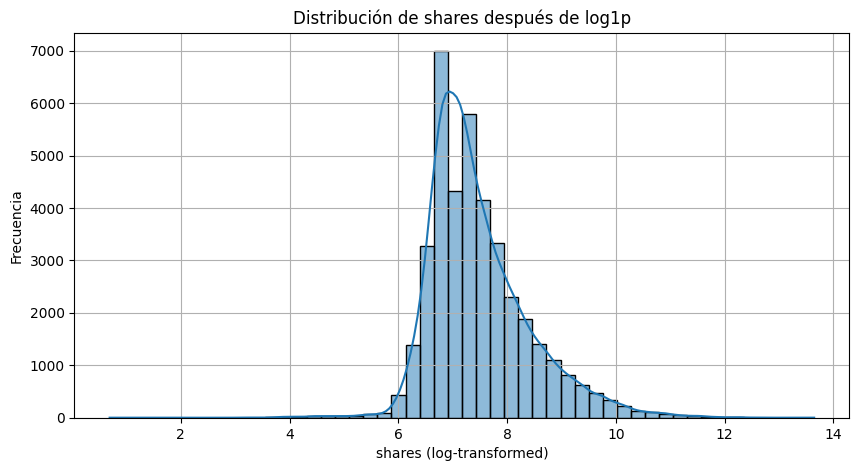

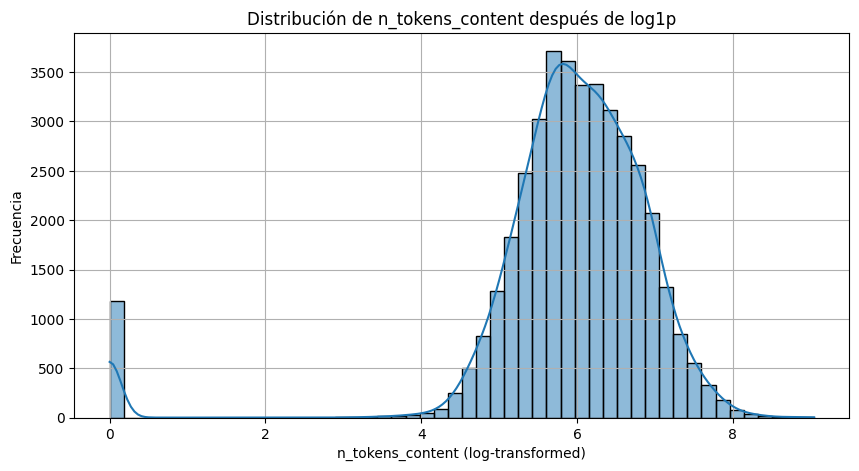

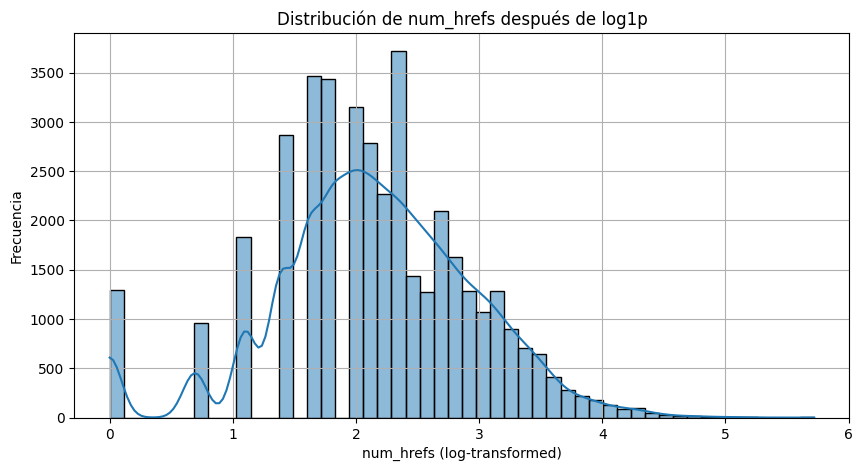

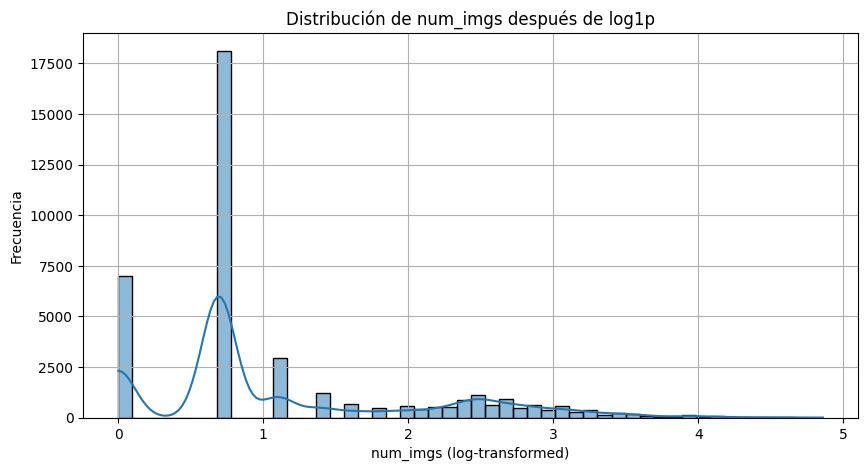

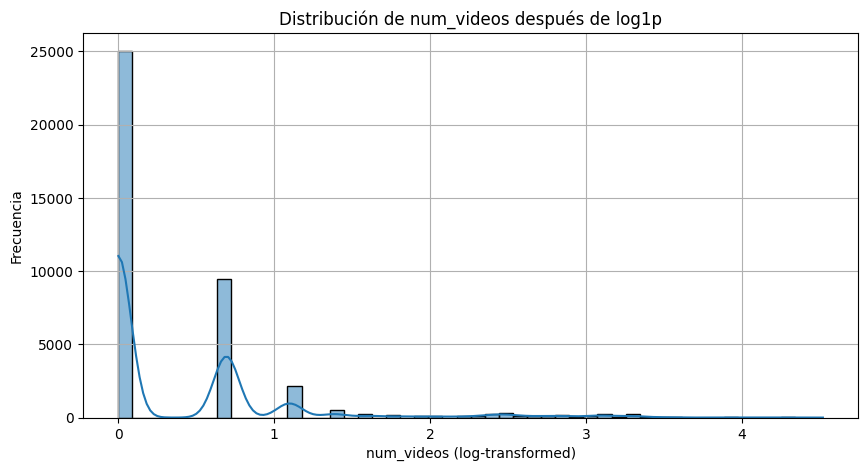

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

for feature in skewed_features:
    plt.figure(figsize=(10, 5))
    sns.histplot(df_transformed[feature], bins=50, kde=True)
    plt.title(f'Distribución de {feature} después de log1p')
    plt.xlabel(f'{feature} (log-transformed)')
    plt.ylabel('Frecuencia')
    plt.grid(True)
    plt.show()


### 2.4 Ingeniería de Características utilizando Selección de Características Basada en Random Forest

Para identificar las características con mayor causalidad para la variable objetivo 'shares', utilizaremos un enfoque basado en `RandomForestRegressor` de `sklearn`. Este método nos permitirá extraer la importancia de cada característica para predecir 'shares'. Luego, usaremos `SelectFromModel` para seleccionar las características más relevantes.

**Nota sobre RFHFS**: El método Random Forest-based Hybrid Feature Selection (RFHFS) es una técnica más específica que podría requerir una implementación personalizada o una librería menos común. Para este caso, utilizaremos la capacidad intrínseca de `RandomForestRegressor` para calcular la importancia de las características, que es un método robusto y ampliamente utilizado para la selección de características en problemas de regresión.

In [22]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.feature_selection import SelectFromModel

# Excluir la columna 'url' ya que no es numérica y no la transformamos.
# La columna 'shares' es la variable objetivo y ya está transformada.
X = df_transformed.drop(['url', 'shares'], axis=1)
y = df_transformed['shares']

# Dividir los datos en conjuntos de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Inicializar y entrenar un RandomForestRegressor
# Se usa n_estimators=100 por defecto para un buen balance entre rendimiento y tiempo de ejecución
# random_state para reproducibilidad
rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1) # n_jobs=-1 para usar todos los cores disponibles
rf_model.fit(X_train, y_train)

# Extraer la importancia de las características
feature_importances = pd.Series(rf_model.feature_importances_, index=X.columns).sort_values(ascending=False)

print("\nImportancia de las características según Random Forest:")
display(feature_importances)

# Seleccionar características importantes usando SelectFromModel
# Se puede ajustar el umbral (threshold) para seleccionar más o menos características
# 'median' es un buen punto de partida para el umbral
selector = SelectFromModel(rf_model, prefit=True, threshold='median')

X_selected = selector.transform(X)

# Obtener los nombres de las características seleccionadas
selected_features_names = X.columns[selector.get_support()]

print("\nNúmero de características originales:", X.shape[1])
print("Número de características seleccionadas:", X_selected.shape[1])
print("Características seleccionadas:")
print(list(selected_features_names))

# Crear un DataFrame con las características seleccionadas
df_selected_features = df_transformed[selected_features_names.tolist() + ['shares']]

print("\nPrimeras 5 filas del DataFrame con características seleccionadas:")
display(df_selected_features.head())



Importancia de las características según Random Forest:


,0
kw_avg_avg,0.089115
timedelta,0.041137
kw_max_avg,0.039103
self_reference_avg_sharess,0.035076
LDA_01,0.030063
kw_avg_max,0.029890
LDA_04,0.029770
self_reference_min_shares,0.029590
global_subjectivity,0.029413
average_token_length,0.028326


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but SelectFromModel was fitted without feature names
  warnings.warn(



Número de características originales: 59
Número de características seleccionadas: 30
Características seleccionadas:
['timedelta', 'n_tokens_title', 'n_tokens_content', 'n_unique_tokens', 'n_non_stop_unique_tokens', 'num_hrefs', 'num_imgs', 'average_token_length', 'kw_max_min', 'kw_avg_min', 'kw_min_max', 'kw_avg_max', 'kw_min_avg', 'kw_max_avg', 'kw_avg_avg', 'self_reference_min_shares', 'self_reference_max_shares', 'self_reference_avg_sharess', 'LDA_00', 'LDA_01', 'LDA_02', 'LDA_03', 'LDA_04', 'global_subjectivity', 'global_sentiment_polarity', 'global_rate_positive_words', 'global_rate_negative_words', 'avg_positive_polarity', 'avg_negative_polarity', 'title_sentiment_polarity']

Primeras 5 filas del DataFrame con características seleccionadas:


,timedelta,n_tokens_title,n_tokens_content,n_unique_tokens,n_non_stop_unique_tokens,num_hrefs,num_imgs,average_token_length,kw_max_min,kw_avg_min,...,LDA_03,LDA_04,global_subjectivity,global_sentiment_polarity,global_rate_positive_words,global_rate_negative_words,avg_positive_polarity,avg_negative_polarity,title_sentiment_polarity,shares
0,731.0,12.0,5.393628,0.663594,0.815385,1.609438,0.693147,4.680365,0.0,0.0,...,0.041263,0.040123,0.521617,0.092562,0.045662,0.013699,0.378636,-0.350000,-0.187500,6.386879
1,731.0,9.0,5.545177,0.604743,0.791946,1.386294,0.693147,4.913725,0.0,0.0,...,0.050101,0.050001,0.341246,0.148948,0.043137,0.015686,0.286915,-0.118750,0.000000,6.568078
2,731.0,9.0,5.356586,0.575130,0.663866,1.386294,0.693147,4.393365,0.0,0.0,...,0.033334,0.682188,0.702222,0.323333,0.056872,0.009479,0.495833,-0.466667,0.000000,7.313887
3,731.0,9.0,6.276643,0.503788,0.665635,2.302585,0.693147,4.404896,0.0,0.0,...,0.028905,0.028572,0.429850,0.100705,0.041431,0.020716,0.385965,-0.369697,0.000000,7.090910
4,731.0,13.0,6.978214,0.415646,0.540890,2.995732,3.044522,4.682836,0.0,0.0,...,0.028572,0.885427,0.513502,0.281003,0.074627,0.012127,0.411127,-0.220192,0.136364,6.226537


## 3. Entrenamiento y Evaluación del Modelo de Regresión

### 3.1 División de los Datos en Conjuntos de Entrenamiento y Prueba

Vamos a dividir el `df_selected_features` en conjuntos de entrenamiento y prueba. Esto nos permitirá entrenar el modelo con un subconjunto de los datos y evaluar su rendimiento con datos que no ha visto antes.

In [26]:
from sklearn.model_selection import train_test_split

X_model = df_selected_features.drop('shares', axis=1)
y_model = df_selected_features['shares']

X_train_model, X_test_model, y_train_model, y_test_model = train_test_split(X_model, y_model, test_size=0.2, random_state=42)

print(f"Dimensiones de X_train: {X_train_model.shape}")
print(f"Dimensiones de X_test: {X_test_model.shape}")
print(f"Dimensiones de y_train: {y_train_model.shape}")
print(f"Dimensiones de y_test: {y_test_model.shape}")

Dimensiones de X_train: (31715, 30)
Dimensiones de X_test: (7929, 30)
Dimensiones de y_train: (31715,)
Dimensiones de y_test: (7929,)


### 3.2 Entrenamiento del Modelo Random Forest Regressor

Entrenaremos un `RandomForestRegressor` utilizando las características seleccionadas. Este modelo es robusto y suele ofrecer un buen rendimiento en problemas de regresión.

In [27]:
from sklearn.ensemble import RandomForestRegressor

# Inicializar el modelo Random Forest Regressor
# Usamos los mismos parámetros que para la selección de características para coherencia
rf_regressor = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)

# Entrenar el modelo
rf_regressor.fit(X_train_model, y_train_model)

print("Modelo Random Forest Regressor entrenado exitosamente.")

Modelo Random Forest Regressor entrenado exitosamente.


### 3.3 Evaluación del Rendimiento del Modelo

Evaluaremos el rendimiento del modelo utilizando métricas clave como el error cuadrático medio (RMSE) y el coeficiente de determinación (R-squared). También visualizaremos las predicciones vs. los valores reales.

In [ ]:
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Realizar predicciones en el conjunto de prueba
y_pred_model = rf_regressor.predict(X_test_model)

# Calcular métricas de evaluación
mse = mean_squared_error(y_test_model, y_pred_model)
rmse = np.sqrt(mse)
r2 = r2_score(y_test_model, y_pred_model)

print(f"\nError Cuadrático Medio (MSE): {mse:.4f}")
print(f"Raíz del Error Cuadrático Medio (RMSE): {rmse:.4f}")
print(f"Coeficiente de Determinación (R-squared): {r2:.4f}")

# Visualizar predicciones vs. valores reales
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test_model, y=y_pred_model, alpha=0.6)
plt.plot([min(y_test_model), max(y_test_model)], [min(y_test_model), max(y_test_model)], color='red', linestyle='--') # Línea de referencia ideal
plt.title('Predicciones vs. Valores Reales (conjunto de prueba)')
plt.xlabel('Valores Reales (shares log-transformados)')
plt.ylabel('Predicciones (shares log-transformados)')
plt.grid(True)
plt.show()

### 3.4 Resumen del Entrenamiento y Evaluación del Modelo

Aquí un breve resumen de los resultados del entrenamiento del modelo.

El DataFrame `df_selected_features` ahora contiene la variable objetivo transformada (`shares`) y las características seleccionadas por el modelo Random Forest. Estas características están listas para ser utilizadas en el entrenamiento de un modelo de regresión.

## 4. Optimización de Hiperparámetros del Modelo Random Forest

Dado el rendimiento inicial del modelo, vamos a realizar una optimización de hiperparámetros para el `RandomForestRegressor` utilizando `RandomizedSearchCV`. Esto nos permitirá buscar una mejor combinación de parámetros que pueda mejorar la precisión del modelo.

In [28]:
from sklearn.model_selection import RandomizedSearchCV

# Definir la cuadrícula de parámetros a buscar
param_dist = {
    'n_estimators': [100, 200, 300, 500],  # Número de árboles en el bosque
    'max_features': ['auto', 'sqrt', 'log2'], # Número de características a considerar para la mejor división
    'max_depth': [10, 20, 30, None], # Profundidad máxima del árbol
    'min_samples_split': [2, 5, 10], # Número mínimo de muestras requeridas para dividir un nodo interno
    'min_samples_leaf': [1, 2, 4], # Número mínimo de muestras requeridas para estar en un nodo hoja
    'bootstrap': [True, False] # Método de muestreo para el entrenamiento de los árboles
}

# Inicializar el modelo base
rf = RandomForestRegressor(random_state=42, n_jobs=-1)

# Inicializar RandomizedSearchCV
# n_iter = 50 indica el número de combinaciones de parámetros a probar.
# cv = 3 para validación cruzada de 3 pliegues.
random_search = RandomizedSearchCV(estimator=rf, param_distributions=param_dist,
                                   n_iter=50, cv=3, verbose=2, random_state=42, n_jobs=-1, scoring='r2')

# Ejecutar la búsqueda
random_search.fit(X_train_model, y_train_model)

print("Mejores hiperparámetros encontrados:", random_search.best_params_)
print("Mejor puntuación R-squared obtenida (en el conjunto de entrenamiento/validación):", random_search.best_score_)

# Asignar el mejor estimador al modelo optimizado
rf_regressor_optimized = random_search.best_estimator_


Fitting 3 folds for each of 50 candidates, totalling 150 fits


/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py:528: FitFailedWarning: 
45 fits failed out of a total of 150.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
18 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.12/dist-packages/sklearn/base.py", l

Mejores hiperparámetros encontrados: {'n_estimators': 300, 'min_samples_split': 2, 'min_samples_leaf': 4, 'max_features': 'sqrt', 'max_depth': None, 'bootstrap': False}
Mejor puntuación R-squared obtenida (en el conjunto de entrenamiento/validación): 0.1524665115321119


## 5. Reevaluación del Modelo con Hiperparámetros Optimizados

Ahora evaluaremos el rendimiento del modelo `RandomForestRegressor` con los hiperparámetros optimizados en el conjunto de prueba.


--- Rendimiento del Modelo Random Forest Optimizado ---
Error Cuadrático Medio (MSE) Optimizado: 0.7145
Raíz del Error Cuadrático Medio (RMSE) Optimizado: 0.8453
Coeficiente de Determinación (R-squared) Optimizado: 0.1665


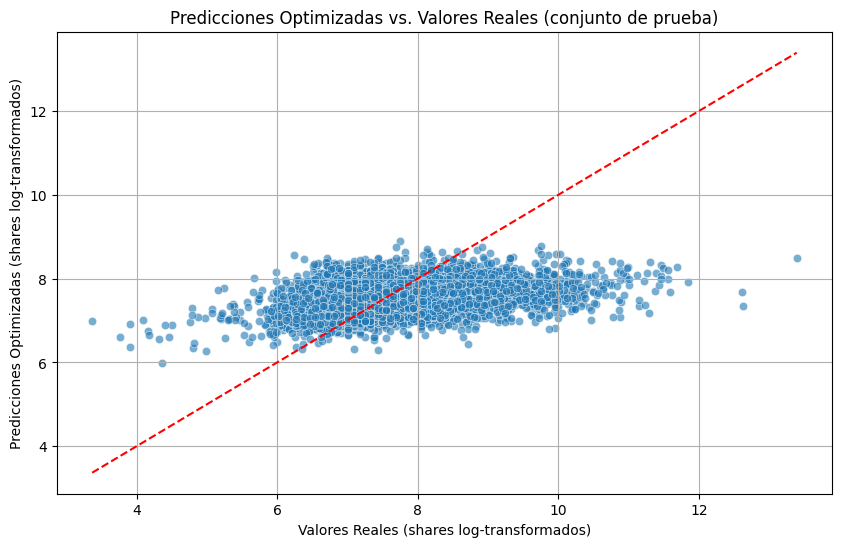

In [29]:
from sklearn.metrics import mean_squared_error, r2_score

# Realizar predicciones con el modelo optimizado
y_pred_optimized = rf_regressor_optimized.predict(X_test_model)

# Calcular métricas de evaluación para el modelo optimizado
mse_optimized = mean_squared_error(y_test_model, y_pred_optimized)
rmse_optimized = np.sqrt(mse_optimized)
r2_optimized = r2_score(y_test_model, y_pred_optimized)

print(f"\n--- Rendimiento del Modelo Random Forest Optimizado ---")
print(f"Error Cuadrático Medio (MSE) Optimizado: {mse_optimized:.4f}")
print(f"Raíz del Error Cuadrático Medio (RMSE) Optimizado: {rmse_optimized:.4f}")
print(f"Coeficiente de Determinación (R-squared) Optimizado: {r2_optimized:.4f}")

# Visualizar predicciones vs. valores reales para el modelo optimizado
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test_model, y=y_pred_optimized, alpha=0.6)
plt.plot([min(y_test_model), max(y_test_model)], [min(y_test_model), max(y_test_model)], color='red', linestyle='--') # Línea de referencia ideal
plt.title('Predicciones Optimizadas vs. Valores Reales (conjunto de prueba)')
plt.xlabel('Valores Reales (shares log-transformados)')
plt.ylabel('Predicciones Optimizadas (shares log-transformados)')
plt.grid(True)
plt.show()


### Resumen de la Optimización del Modelo

Los resultados de la optimización del Random Forest muestran si se lograron mejoras en el rendimiento predictivo.




## Mejores hiperparámetros encontrados por RandomizedSearchCV:
 {'n_estimators': 300, 'min_samples_split': 2, 'min_samples_leaf': 4, 'max_features': 'sqrt', 'max_depth': None, 'bootstrap': False}

Rendimiento del Modelo Random Forest Optimizado (en el conjunto de prueba):

Error Cuadrático Medio (MSE) Optimizado: 0.7145
Raíz del Error Cuadrático Medio (RMSE) Optimizado: 0.8453
Coeficiente de Determinación (R-squared) Optimizado: 0.1665
Comparación con el modelo inicial:

R-squared inicial: 0.1483
R-squared optimizado: 0.1665
Vemos una ligera mejora en el rendimiento del modelo tras la optimización de hiperparámetros, con un aumento del R-squared de aproximadamente 0.1483 a 0.1665. Esto significa que el modelo optimizado explica un porcentaje ligeramente mayor de la varianza en las 'shares'. Aunque la mejora es modesta, es un paso en la dirección correcta.

También es importante mencionar que durante la ejecución de RandomizedSearchCV, se mostraron algunas advertencias (FitFailedWarning) debido a que el valor 'auto' para max_features ya no es válido en las versiones más recientes de scikit-learn. El optimizador automáticamente evitó estas combinaciones y encontró un conjunto de parámetros válidos, siendo 'sqrt' la mejor opción para max_features en este caso.

## 6. Exploración de Modelos Alternativos: LightGBM Regressor

Dado el rendimiento del Random Forest, exploraremos un modelo de regresión alternativo: LightGBM. Este algoritmo es conocido por su velocidad y eficiencia, además de ofrecer un buen rendimiento en diversas tareas de aprendizaje automático.

In [30]:
import lightgbm as lgb
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Inicializar el modelo LightGBM Regressor
# Usaremos algunos hiperparámetros predeterminados para una primera aproximación
lgbm_regressor = lgb.LGBMRegressor(random_state=42, n_jobs=-1)

# Entrenar el modelo
lgbm_regressor.fit(X_train_model, y_train_model)

print("Modelo LightGBM Regressor entrenado exitosamente.")

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.011130 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 7025
[LightGBM] [Info] Number of data points in the train set: 31715, number of used features: 30
[LightGBM] [Info] Start training from score 7.477650
Modelo LightGBM Regressor entrenado exitosamente.


### 6.1 Evaluación del Rendimiento del Modelo LightGBM

Evaluaremos el rendimiento del modelo LightGBM utilizando las mismas métricas (MSE, RMSE, R-squared) y visualizaciones que antes.


--- Rendimiento del Modelo LightGBM ---
Error Cuadrático Medio (MSE) LightGBM: 0.7173
Raíz del Error Cuadrático Medio (RMSE) LightGBM: 0.8469
Coeficiente de Determinación (R-squared) LightGBM: 0.1633


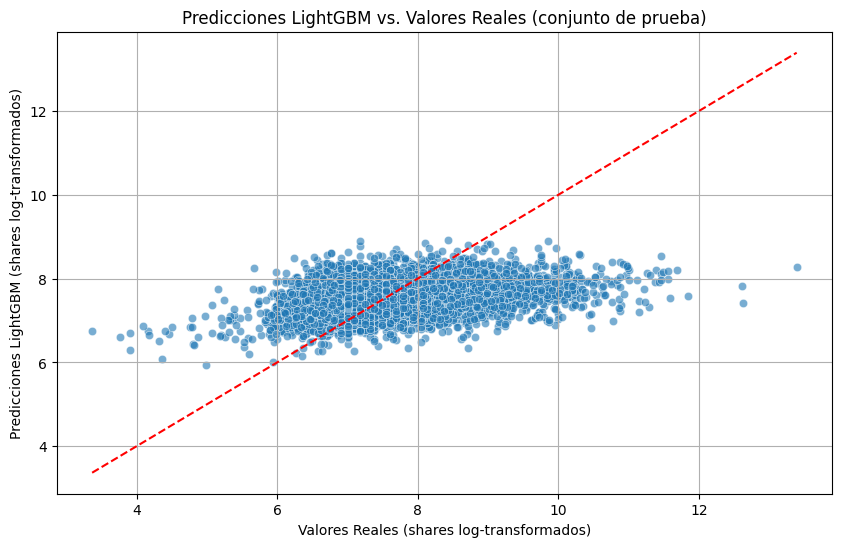

In [31]:
# Realizar predicciones en el conjunto de prueba
y_pred_lgbm = lgbm_regressor.predict(X_test_model)

# Calcular métricas de evaluación
mse_lgbm = mean_squared_error(y_test_model, y_pred_lgbm)
rmse_lgbm = np.sqrt(mse_lgbm)
r2_lgbm = r2_score(y_test_model, y_pred_lgbm)

print(f"\n--- Rendimiento del Modelo LightGBM ---")
print(f"Error Cuadrático Medio (MSE) LightGBM: {mse_lgbm:.4f}")
print(f"Raíz del Error Cuadrático Medio (RMSE) LightGBM: {rmse_lgbm:.4f}")
print(f"Coeficiente de Determinación (R-squared) LightGBM: {r2_lgbm:.4f}")

# Visualizar predicciones vs. valores reales para el modelo LightGBM
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test_model, y=y_pred_lgbm, alpha=0.6)
plt.plot([min(y_test_model), max(y_test_model)], [min(y_test_model), max(y_test_model)], color='red', linestyle='--') # Línea de referencia ideal
plt.title('Predicciones LightGBM vs. Valores Reales (conjunto de prueba)')
plt.xlabel('Valores Reales (shares log-transformados)')
plt.ylabel('Predicciones LightGBM (shares log-transformados)')
plt.grid(True)
plt.show()

## 7. Optimización de Hiperparámetros del Modelo LightGBM

Continuando con la exploración de modelos, ahora realizaremos una optimización de hiperparámetros para el `LGBMRegressor` utilizando `RandomizedSearchCV`. Esto nos permitirá buscar una mejor combinación de parámetros que pueda mejorar la precisión del modelo LightGBM.

In [32]:
from sklearn.model_selection import RandomizedSearchCV
import lightgbm as lgb

# Definir la cuadrícula de parámetros a buscar para LightGBM
param_dist_lgbm = {
    'n_estimators': [100, 200, 300, 500, 700],
    'learning_rate': [0.01, 0.05, 0.1, 0.15, 0.2],
    'num_leaves': [20, 31, 40, 50], # Default is 31
    'max_depth': [-1, 10, 20, 30], # Default is -1 (no limit)
    'min_child_samples': [20, 30, 40, 50], # Default is 20
    'subsample': [0.6, 0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.6, 0.7, 0.8, 0.9, 1.0],
    'reg_alpha': [0, 0.1, 0.5, 1.0],
    'reg_lambda': [0, 0.1, 0.5, 1.0],
}

# Inicializar el modelo base LightGBM
lgbm = lgb.LGBMRegressor(random_state=42, n_jobs=-1)

# Inicializar RandomizedSearchCV para LightGBM
# n_iter = 50 es un buen balance para explorar el espacio de búsqueda
random_search_lgbm = RandomizedSearchCV(estimator=lgbm, param_distributions=param_dist_lgbm,
                                      n_iter=50, cv=3, verbose=2, random_state=42, n_jobs=-1, scoring='r2')

# Ejecutar la búsqueda
random_search_lgbm.fit(X_train_model, y_train_model)

print("Mejores hiperparámetros encontrados para LightGBM:", random_search_lgbm.best_params_)
print("Mejor puntuación R-squared obtenida para LightGBM (en el conjunto de entrenamiento/validación):", random_search_lgbm.best_score_)

# Asignar el mejor estimador al modelo LightGBM optimizado
lgbm_regressor_optimized = random_search_lgbm.best_estimator_


Fitting 3 folds for each of 50 candidates, totalling 150 fits
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.010105 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 7025
[LightGBM] [Info] Number of data points in the train set: 31715, number of used features: 30
[LightGBM] [Info] Start training from score 7.477650
Mejores hiperparámetros encontrados para LightGBM: {'subsample': 0.9, 'reg_lambda': 1.0, 'reg_alpha': 0.5, 'num_leaves': 50, 'n_estimators': 700, 'min_child_samples': 30, 'max_depth': -1, 'learning_rate': 0.01, 'colsample_bytree': 0.8}
Mejor puntuación R-squared obtenida para LightGBM (en el conjunto de entrenamiento/validación): 0.16077661954204556


## 8. Reevaluación del Modelo LightGBM con Hiperparámetros Optimizados

Ahora evaluaremos el rendimiento del modelo `LGBMRegressor` con los hiperparámetros optimizados en el conjunto de prueba y compararemos con los modelos anteriores.


--- Rendimiento del Modelo LightGBM Optimizado ---
Error Cuadrático Medio (MSE) LightGBM Optimizado: 0.7109
Raíz del Error Cuadrático Medio (RMSE) LightGBM Optimizado: 0.8432
Coeficiente de Determinación (R-squared) LightGBM Optimizado: 0.1707


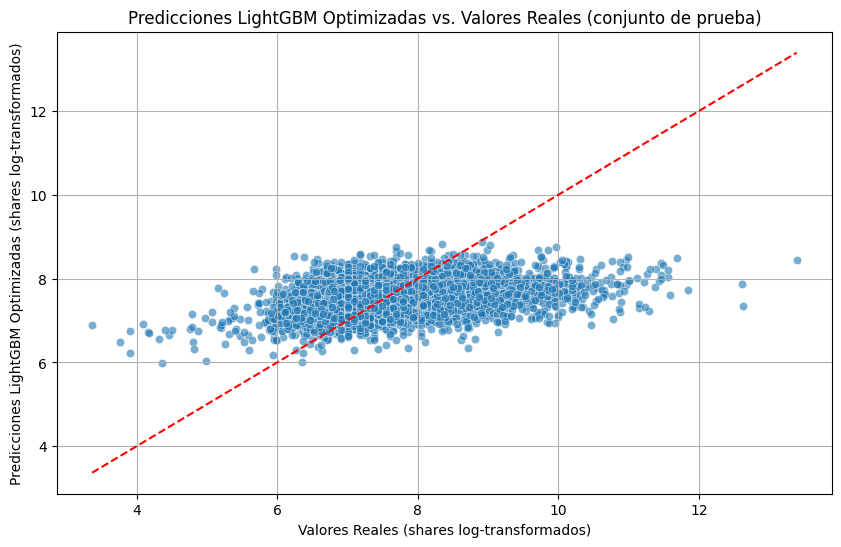

In [33]:
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Realizar predicciones con el modelo LightGBM optimizado
y_pred_lgbm_optimized = lgbm_regressor_optimized.predict(X_test_model)

# Calcular métricas de evaluación para el modelo LightGBM optimizado
mse_lgbm_optimized = mean_squared_error(y_test_model, y_pred_lgbm_optimized)
rmse_lgbm_optimized = np.sqrt(mse_lgbm_optimized)
r2_lgbm_optimized = r2_score(y_test_model, y_pred_lgbm_optimized)

print(f"\n--- Rendimiento del Modelo LightGBM Optimizado ---")
print(f"Error Cuadrático Medio (MSE) LightGBM Optimizado: {mse_lgbm_optimized:.4f}")
print(f"Raíz del Error Cuadrático Medio (RMSE) LightGBM Optimizado: {rmse_lgbm_optimized:.4f}")
print(f"Coeficiente de Determinación (R-squared) LightGBM Optimizado: {r2_lgbm_optimized:.4f}")

# Visualizar predicciones vs. valores reales para el modelo LightGBM optimizado
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test_model, y=y_pred_lgbm_optimized, alpha=0.6)
plt.plot([min(y_test_model), max(y_test_model)], [min(y_test_model), max(y_test_model)], color='red', linestyle='--') # Línea de referencia ideal
plt.title('Predicciones LightGBM Optimizadas vs. Valores Reales (conjunto de prueba)')
plt.xlabel('Valores Reales (shares log-transformados)')
plt.ylabel('Predicciones LightGBM Optimizadas (shares log-transformados)')
plt.grid(True)
plt.show()

### Resumen de la Optimización del Modelo LightGBM y Comparativa Final

Analizaremos los resultados de la optimización de LightGBM y realizaremos una comparativa final entre todos los modelos evaluados.